In [1]:
from transformers import AutoModelForCausalLM, AutoModelForSequenceClassification, AutoModelForQuestionAnswering, AutoTokenizer


ModuleNotFoundError: No module named 'transformers'

In [ ]:
MODEL_NAME = "Qwen/Qwen3.5-2B"
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3.5-2B")


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
len(model.model.layers)

In [ ]:
import torch
import copy

def truncate_qwen_like_model_once(model, layer_index):
    """
    Keep layers 0..layer_index inclusive.

    Works for Qwen/Llama-style AutoModelForCausalLM where transformer blocks are:
        model.model.layers
    """
    num_layers_to_keep = layer_index + 1

    layers = model.model.layers

    model.model.layers = torch.nn.ModuleList(
        list(layers[:num_layers_to_keep])
    )

    model.config.num_hidden_layers = num_layers_to_keep
    model.model.config.num_hidden_layers = num_layers_to_keep

    return model

In [ ]:
full_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

draft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

layer_index = 6
draft_model = truncate_qwen_like_model_once(draft_model, layer_index)

print("full layers:", len(full_model.model.layers))
print("draft layers:", len(draft_model.model.layers))

In [ ]:
@torch.no_grad()
def next_probs_up_to_layer(
    draft_model,
    input_ids,
    temperature=1.0,
):
    """
    Run truncated draft_model and return next-token probabilities.

    Args:
        draft_model: already truncated model
        input_ids: [B, T]
        temperature: sampling temperature

    Returns:
        probs:  [B, vocab]
        logits: [B, vocab]
    """
    attention_mask = torch.ones_like(input_ids, device=input_ids.device)

    outputs = draft_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    )

    next_logits = outputs.logits[:, -1, :]  # [B, vocab]

    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    probs = torch.softmax(next_logits.float() / temperature, dim=-1)

    return probs, next_logits

In [ ]:
import torch
from tqdm.auto import trange

@torch.no_grad()
def print_topk_by_truncating_last_layers(
    model,
    tokenizer,
    text,
    top_k=10,
    max_layers_to_test=None,
):
    """
    Iteratively remove last layer and print top-k next-token predictions.

    No try/finally version.
    If this crashes midway, reload the model.
    """
    model.eval()

    device = next(model.parameters()).device

    input_ids = tokenizer(
        text,
        return_tensors="pt",
    )["input_ids"].to(device)

    attention_mask = torch.ones_like(input_ids, device=device)

    original_layers = list(model.model.layers)
    n_layers = len(original_layers)

    if max_layers_to_test is None:
        max_layers_to_test = n_layers

    max_layers_to_test = min(max_layers_to_test, n_layers)

    removed_layers = []

    for removed_count in trange(max_layers_to_test + 1, desc="Testing truncations"):
        current_num_layers = len(model.model.layers)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        next_logits = outputs.logits[:, -1, :]
        probs = torch.softmax(next_logits.float(), dim=-1)

        top = torch.topk(probs[0], k=top_k)

        print()
        print("=" * 80)
        print(f"Removed layers: {removed_count}")
        print(f"Remaining layers: {current_num_layers}/{n_layers}")
        print(f"Prompt: {text!r}")
        print("-" * 80)

        for rank, (token_id, prob) in enumerate(zip(top.indices, top.values), start=1):
            token_id = token_id.item()
            token_text = tokenizer.decode([token_id])
            print(f"{rank:02d}. {token_text!r:20s} prob={prob.item():.6f} id={token_id}")

        if removed_count < max_layers_to_test:
            removed_layer = model.model.layers.pop(-1)
            removed_layers.append(removed_layer)

            model.config.num_hidden_layers = len(model.model.layers)
            model.model.config.num_hidden_layers = len(model.model.layers)

    # Restore model layers at the end.
    model.model.layers = torch.nn.ModuleList(original_layers)
    model.config.num_hidden_layers = n_layers
    model.model.config.num_hidden_layers = n_layers

    print()
    print("Restored model layers:", len(model.model.layers), "/", n_layers)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


In [ ]:

print_topk_by_truncating_last_layers(
    model=model,
    tokenizer=tokenizer,
    text="The future of artificial intelligence is",
    top_k=5,
    max_layers_to_test=None,
)

In [ ]:
draft_model.model.layers

In [ ]:
from datasets import load_dataset
# use name="sample-10BT" to use the 10BT sample
fw = load_dataset("HuggingFaceFW/fineweb-edu", name="CC-MAIN-2024-10", split="train", streaming=True)

***

### Training Adapters:

In [1]:
!pip uninstall -y tokenizers transformers
!pip install -U "tokenizers>=0.22.0,<=0.23.0"
!pip install -U git+https://github.com/huggingface/transformers.git
!pip install -U accelerate safetensors huggingface_hub

Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: transformers 5.12.0
Uninstalling transformers-5.12.0:
  Successfully uninstalled transformers-5.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 26.0 MB/s eta 0:00:00
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-efbs7eh9
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-efbs7eh9
  Resolved https://github.com/huggingface/transformers.git to commit 4fd7f1a05f52a11d7709747be554ca50294bf03f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.13.0.dev0-py3-none-any.whl size=12547641 sha256=6e9c3e965548af0739f41cc2367a1f541e0392fe8f0ad6fa83d8f69d7027e3d7
  Stored in directory: /tmp/pip-e

In [6]:
# ============================================================
# 1. Imports
# ============================================================

import os
import wandb
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

# ============================================================
# 2. Wandb Helper
# ============================================================

def build_layer_metrics_table_for_wandb(step, split, layer_metrics):
    import wandb

    table = wandb.Table(
        columns=[
            "step",
            "split",
            "layer",
            "kl_loss",
            "metric_kl",
            "ce",
            "top1",
            "topk_overlap",
            "accept_exact",
            "accept_sampled",
        ]
    )

    for row in layer_metrics:
        table.add_data(
            step,
            split,
            row["layer"],
            row.get("kl_loss"),
            row.get("metric_kl"),
            row.get("ce"),
            row.get("top1"),
            row.get("topk_overlap"),
            row.get("accept_exact"),
            row.get("accept_sampled"),
        )

    return {
        f"{split}/layer_metrics_table": table
    }


def build_layer_metric_plots_for_wandb(step, split, layer_metrics):
    import wandb

    table = wandb.Table(
        columns=[
            "layer",
            "kl_loss",
            "metric_kl",
            "ce",
            "top1",
            "topk_overlap",
            "accept_exact",
            "accept_sampled",
        ]
    )

    for row in layer_metrics:
        table.add_data(
            row["layer"],
            row.get("kl_loss"),
            row.get("metric_kl"),
            row.get("ce"),
            row.get("top1"),
            row.get("topk_overlap"),
            row.get("accept_exact"),
            row.get("accept_sampled"),
        )

    return {
        f"{split}/kl_by_layer": wandb.plot.line(
            table, "layer", "metric_kl", title=f"{split} KL by layer"
        ),
        f"{split}/ce_by_layer": wandb.plot.line(
            table, "layer", "ce", title=f"{split} CE by layer"
        ),
        f"{split}/top1_by_layer": wandb.plot.line(
            table, "layer", "top1", title=f"{split} top1 by layer"
        ),
        f"{split}/accept_exact_by_layer": wandb.plot.line(
            table, "layer", "accept_exact", title=f"{split} accept exact by layer"
        ),
        f"{split}/accept_sampled_by_layer": wandb.plot.line(
            table, "layer", "accept_sampled", title=f"{split} accept sampled by layer"
        ),
    }

def metric_row(layer_index, metrics, top_k, kl_loss=None):
    return {
        "layer": layer_index,
        "kl_loss": kl_loss,
        "metric_kl": metrics["kl_to_teacher"],
        "ce": metrics["ce"],
        "top1": metrics["top1_teacher_agreement"],
        "topk_overlap": metrics[f"top{top_k}_overlap"],
        "accept_exact": metrics["accept_proxy_exact"],
        "accept_sampled": metrics["accept_proxy_sampled"],
    }


def add_rows_to_wandb_log(wandb_log, step, split, rows):
    wandb_log.update(
        build_layer_metrics_table_for_wandb(
            step=step,
            split=split,
            layer_metrics=rows,
        )
    )
    wandb_log.update(
        build_layer_metric_plots_for_wandb(
            step=step,
            split=split,
            layer_metrics=rows,
        )
    )


def add_scalar_rows_to_wandb_log(wandb_log, split, rows, top_k):
    for row in rows:
        layer = row["layer"]
        prefix = f"{split}/layer_{layer:02d}"

        wandb_log.update({
            f"{prefix}/metric_kl": row["metric_kl"],
            f"{prefix}/ce": row["ce"],
            f"{prefix}/top1": row["top1"],
            f"{prefix}/top{top_k}_overlap": row["topk_overlap"],
            f"{prefix}/accept_exact": row["accept_exact"],
            f"{prefix}/accept_sampled": row["accept_sampled"],
        })

        if row["kl_loss"] is not None:
            wandb_log[f"{prefix}/kl_loss"] = row["kl_loss"]


def eval_rows_from_metrics(eval_metrics, candidate_layers, top_k):
    baseline_rows = []
    adapted_rows = []
    improvement_rows = []

    for layer in candidate_layers:
        b = f"layer_{layer}/eval_baseline"
        a = f"layer_{layer}/eval_adapted"

        baseline = metric_row(
            layer,
            {
                "kl_to_teacher": eval_metrics[f"{b}/kl_to_teacher"],
                "ce": eval_metrics[f"{b}/ce"],
                "top1_teacher_agreement": eval_metrics[f"{b}/top1_teacher_agreement"],
                f"top{top_k}_overlap": eval_metrics[f"{b}/top{top_k}_overlap"],
                "accept_proxy_exact": eval_metrics[f"{b}/accept_proxy_exact"],
                "accept_proxy_sampled": eval_metrics[f"{b}/accept_proxy_sampled"],
            },
            top_k,
        )

        adapted = metric_row(
            layer,
            {
                "kl_to_teacher": eval_metrics[f"{a}/kl_to_teacher"],
                "ce": eval_metrics[f"{a}/ce"],
                "top1_teacher_agreement": eval_metrics[f"{a}/top1_teacher_agreement"],
                f"top{top_k}_overlap": eval_metrics[f"{a}/top{top_k}_overlap"],
                "accept_proxy_exact": eval_metrics[f"{a}/accept_proxy_exact"],
                "accept_proxy_sampled": eval_metrics[f"{a}/accept_proxy_sampled"],
            },
            top_k,
        )

        improvement = {
            "layer": layer,
            "kl_loss": None,
            "metric_kl": baseline["metric_kl"] - adapted["metric_kl"],
            "ce": baseline["ce"] - adapted["ce"],
            "top1": adapted["top1"] - baseline["top1"],
            "topk_overlap": adapted["topk_overlap"] - baseline["topk_overlap"],
            "accept_exact": adapted["accept_exact"] - baseline["accept_exact"],
            "accept_sampled": adapted["accept_sampled"] - baseline["accept_sampled"],
        }

        baseline_rows.append(baseline)
        adapted_rows.append(adapted)
        improvement_rows.append(improvement)

    return baseline_rows, adapted_rows, improvement_rows

def build_eval_comparison_plots_for_wandb(step, baseline_rows, adapted_rows):
    import wandb

    layers = [row["layer"] for row in baseline_rows]

    def values(rows, key):
        return [row[key] for row in rows]

    return {
        "eval/kl_baseline_vs_adapted_by_layer": wandb.plot.line_series(
            xs=layers,
            ys=[
                values(baseline_rows, "metric_kl"),
                values(adapted_rows, "metric_kl"),
            ],
            keys=["baseline", "adapted"],
            title="eval KL by layer",
            xname="layer",
        ),
        "eval/ce_baseline_vs_adapted_by_layer": wandb.plot.line_series(
            xs=layers,
            ys=[
                values(baseline_rows, "ce"),
                values(adapted_rows, "ce"),
            ],
            keys=["baseline", "adapted"],
            title="eval CE by layer",
            xname="layer",
        ),
        "eval/top1_baseline_vs_adapted_by_layer": wandb.plot.line_series(
            xs=layers,
            ys=[
                values(baseline_rows, "top1"),
                values(adapted_rows, "top1"),
            ],
            keys=["baseline", "adapted"],
            title="eval top1 by layer",
            xname="layer",
        ),
        "eval/accept_exact_baseline_vs_adapted_by_layer": wandb.plot.line_series(
            xs=layers,
            ys=[
                values(baseline_rows, "accept_exact"),
                values(adapted_rows, "accept_exact"),
            ],
            keys=["baseline", "adapted"],
            title="eval accept exact by layer",
            xname="layer",
        ),
        "eval/accept_sampled_baseline_vs_adapted_by_layer": wandb.plot.line_series(
            xs=layers,
            ys=[
                values(baseline_rows, "accept_sampled"),
                values(adapted_rows, "accept_sampled"),
            ],
            keys=["baseline", "adapted"],
            title="eval accept sampled by layer",
            xname="layer",
        ),
    }

# ============================================================
# 2. Adapter modules
# ============================================================

class ResidualLinearAdapter(nn.Module):
    """
    Simple first adapter:
        h -> h + Linear(LayerNorm(h))

    This is stronger and safer than plain Linear(h).
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.ln = nn.LayerNorm(hidden_size) # Layer that normalizes the input tensor across the last dimension ensuring that the
                                            # mean and variance are consistent.
        self.proj = nn.Linear(hidden_size, hidden_size) # Linear layer that projects the normalized hidden state to the same hidden size.

    def forward(self, h):
        return h + self.proj(self.ln(h))


def build_adapters(model, candidate_layers, device):
    hidden_size = model.config.hidden_size # The hidden size of the last hidden layer in the model.
    model_dtype = next(model.parameters()).dtype

    adapters = nn.ModuleDict({
        str(layer): ResidualLinearAdapter(hidden_size)
        for layer in candidate_layers
    })

    adapters.to(device=device, dtype=model_dtype)
    return adapters


# ============================================================
# 3. Loading
# ============================================================

def load_lm_model_and_tokenizer(model_name, device=None, dtype=None):
    hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if dtype is None:
        dtype = torch.bfloat16 if device == "cuda" else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        token=hf_token,
        trust_remote_code=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        token=hf_token,
        trust_remote_code=True,
    ).to(device)

    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model, tokenizer, device


def load_fineweb_stream(
    dataset_name="HuggingFaceFW/fineweb-edu",
    split="train",
    seed=42,
    buffer_size=10_000,
):
    dataset = load_dataset(
        dataset_name,
        split=split,
        streaming=True,
    )

    dataset = dataset.shuffle(
        seed=seed,
        buffer_size=buffer_size,
    )

    return dataset

def build_fixed_eval_cache_from_stream(
    dataset,
    tokenizer,
    seq_len,
    eval_size,
):
    """
    Consumes the first eval_size token-valid examples from the SAME streaming
    iterator that will later be used for training.

    Returns:
        eval_batches: fixed list of CPU tokenized batches
        train_iter:   remaining stream iterator, starting AFTER eval examples

    This prevents eval/train leakage during this run.
    """
    data_iter = iter(dataset)

    eval_batches = []
    raw_seen = 0

    while len(eval_batches) < eval_size:
        example = next(data_iter)
        raw_seen += 1

        # Keep eval batches on CPU so we do not waste GPU memory.
        batch = tokenize_example(
            example=example,
            tokenizer=tokenizer,
            seq_len=seq_len,
            device="cpu",
        )

        if batch is None:
            continue

        eval_batches.append(batch)

    print(
        f"Built fixed eval cache: {len(eval_batches)} examples "
        f"from {raw_seen} raw stream examples. "
        f"Training continues from the remaining stream."
    )

    return eval_batches, data_iter


# ============================================================
# 4. Tokenization
# ============================================================

def tokenize_example(example, tokenizer, seq_len, device):
    text = example.get("text", "")

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=seq_len,
    )

    input_ids = encoded["input_ids"]

    if input_ids.shape[1] < seq_len:
        return None

    input_ids = input_ids.to(device)
    attention_mask = torch.ones_like(input_ids, device=device)

    return input_ids, attention_mask


# ============================================================
# 5. Logits and losses
# ============================================================

def adapter_hidden_to_logits(model, adapter, hidden_state):
    """
    early hidden -> adapter -> final norm -> lm_head
    """
    adapted_h = adapter(hidden_state) # Getting the adapted hidden state
    adapted_h = model.model.norm(adapted_h) # Applying the final layer normalization to the adapted hidden state
    logits = model.lm_head(adapted_h) # Getting the logits by passing the normalized adapted hidden state through the language model head
    return logits


def kl_distill_loss(student_logits, teacher_logits, temperature=2.0):
    """
    KL(student || teacher target distribution).

    student_logits: [B, T, V]
    teacher_logits: [B, T, V]
    """
    T = temperature

    student_log_probs = F.log_softmax(student_logits / T, dim=-1)
    teacher_probs = F.softmax(teacher_logits / T, dim=-1)

    loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean",
    ) * (T * T)

    return loss


def compute_training_metrics(student_logits, teacher_logits, labels, top_k=5):
    """
    student_logits: [B, T-1, V]
    teacher_logits: [B, T-1, V]
    labels:         [B, T-1]
    """
    with torch.no_grad():
        B, Tm1, V = student_logits.shape

        student_logits_f = student_logits.float()
        teacher_logits_f = teacher_logits.float()

        student_log_probs = F.log_softmax(student_logits_f, dim=-1)
        teacher_log_probs = F.log_softmax(teacher_logits_f, dim=-1)

        student_probs = student_log_probs.exp()
        teacher_probs = teacher_log_probs.exp()

        # KL(teacher || student), averaged per token.
        kl_to_teacher = (
            teacher_probs * (teacher_log_probs - student_log_probs)
        ).sum(dim=-1).mean()

        ce = F.cross_entropy(
            student_logits_f.reshape(-1, V),
            labels.reshape(-1),
            reduction="mean",
        )

        gt_probs = student_probs.gather(
            dim=-1,
            index=labels.unsqueeze(-1),
        ).squeeze(-1)

        teacher_top1 = teacher_logits_f.argmax(dim=-1)
        student_top1 = student_logits_f.argmax(dim=-1)

        top1_agreement = (
            teacher_top1 == student_top1
        ).float().mean()

        teacher_topk = teacher_logits_f.topk(top_k, dim=-1).indices
        student_topk = student_logits_f.topk(top_k, dim=-1).indices

        topk_overlap = (
            teacher_topk.unsqueeze(-1) == student_topk.unsqueeze(-2)
        ).any(dim=-1).float().mean()

        # Exact expected 1-token speculative acceptance:
        # E_{x ~ q}[min(1, p(x)/q(x))] = sum_x min(p(x), q(x))
        accept_proxy_exact = torch.minimum(
            teacher_probs,
            student_probs,
        ).sum(dim=-1).mean()

        # Sampled proxy: closer to the actual sampled rule, but noisier.
        sampled = torch.multinomial(
            student_probs.reshape(-1, V),
            num_samples=1,
        ).reshape(B, Tm1)

        p_token = teacher_probs.gather(
            dim=-1,
            index=sampled.unsqueeze(-1),
        ).squeeze(-1)

        q_token = student_probs.gather(
            dim=-1,
            index=sampled.unsqueeze(-1),
        ).squeeze(-1)

        accept_proxy_sampled = torch.minimum(
            torch.ones_like(p_token),
            p_token / torch.clamp(q_token, min=1e-12),
        ).mean()

        return {
            "kl_to_teacher": float(kl_to_teacher.item()),
            "ce": float(ce.item()),
            "perplexity": float(math.exp(min(ce.item(), 20))),
            "mean_gt_prob": float(gt_probs.mean().item()),
            "top1_teacher_agreement": float(top1_agreement.item()),
            f"top{top_k}_overlap": float(topk_overlap.item()),
            "accept_proxy_exact": float(accept_proxy_exact.item()),
            "accept_proxy_sampled": float(accept_proxy_sampled.item()),
        }

# ============================================================
# 6. Evaluation loop
# ============================================================

@torch.no_grad()
def evaluate_fixed_eval_set(
    model,
    adapters,
    eval_batches,
    candidate_layers,
    top_k=5,
    max_eval_batches=None,
):
    """
    Evaluate the model with adapters on a fixed evaluation set.
    """
    device = next(model.parameters()).device

    was_training = adapters.training
    adapters.eval()

    if max_eval_batches is not None:
        eval_batches_to_use = eval_batches[:max_eval_batches]
    else:
        eval_batches_to_use = eval_batches

    sums = {}
    counts = {}

    for input_ids_cpu, attention_mask_cpu in eval_batches_to_use:
        input_ids = input_ids_cpu.to(device)
        attention_mask = attention_mask_cpu.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

        teacher_logits = outputs.logits[:, :-1, :].detach()
        labels = input_ids[:, 1:]
        hidden_states = outputs.hidden_states

        for layer_index in candidate_layers:
            early_h = hidden_states[layer_index + 1].detach()
            early_h = early_h[:, :-1, :]

            # Baseline: no adapter.
            baseline_h = model.model.norm(early_h)
            baseline_logits = model.lm_head(baseline_h)

            baseline_metrics = compute_training_metrics(
                student_logits=baseline_logits.float(),
                teacher_logits=teacher_logits.float(),
                labels=labels,
                top_k=top_k,
            )

            # Adapted: adapter + final norm + lm_head.
            adapted_logits = adapter_hidden_to_logits(
                model=model,
                adapter=adapters[str(layer_index)],
                hidden_state=early_h,
            )

            adapted_metrics = compute_training_metrics(
                student_logits=adapted_logits.float(),
                teacher_logits=teacher_logits.float(),
                labels=labels,
                top_k=top_k,
            )

            for metric_name, value in baseline_metrics.items():
                key = f"layer_{layer_index}/eval_baseline/{metric_name}"
                sums[key] = sums.get(key, 0.0) + value
                counts[key] = counts.get(key, 0) + 1

            for metric_name, value in adapted_metrics.items():
                key = f"layer_{layer_index}/eval_adapted/{metric_name}"
                sums[key] = sums.get(key, 0.0) + value
                counts[key] = counts.get(key, 0) + 1

    eval_results = {
        key: sums[key] / counts[key]
        for key in sums
    }

    if was_training:
        adapters.train()

    return eval_results


# ============================================================
# 7. Training loop
# ============================================================

def train_initial_adapters(
    model,
    tokenizer,
    dataset,
    candidate_layers,
    seq_len=128,
    max_steps=500,
    lr=1e-4,
    temperature=2.0,
    top_k=5,
    log_every=20,
    eval_step=100,
    eval_size=32,
    eval_max_batches=None,
    save_every=100,
    out_dir="data/early_exit_adapters",
    use_wandb=True,
    wandb_project="qwen35-early-exit-adapters",
    wandb_run_name=None,
    wandb_mode=None):

    os.makedirs(out_dir, exist_ok=True)

    device = next(model.parameters()).device
    num_layers = len(model.model.layers)

    candidate_layers = [
        layer for layer in candidate_layers
        if layer < num_layers
    ]

    print("Training adapters for layers:", candidate_layers)

    adapters = build_adapters(
        model=model,
        candidate_layers=candidate_layers,
        device=device,
    )

    optimizer = torch.optim.AdamW(
        adapters.parameters(),
        lr=lr,
        weight_decay=0.01,
    )
    wandb_run = None

    if use_wandb:
        import wandb

        wandb_run = wandb.init(
            project=wandb_project,
            name=wandb_run_name,
            mode=wandb_mode,
            config={
                "seq_len": seq_len,
                "max_steps": max_steps,
                "lr": lr,
                "temperature": temperature,
                "top_k": top_k,
                "candidate_layers": candidate_layers,
                "log_every": log_every,
                "eval_step": eval_step,
                "eval_size": eval_size,
                "eval_max_batches": eval_max_batches,
                "save_every": save_every,
                "out_dir": out_dir,
                "model_name": getattr(model.config, "_name_or_path", None),
                "adapter_type": "ResidualLinearAdapter",
            },
        )

        wandb.define_metric("step")
        wandb.define_metric("train/*", step_metric="step")
        wandb.define_metric("eval_baseline/*", step_metric="step")
        wandb.define_metric("eval_adapted/*", step_metric="step")
        wandb.define_metric("eval_improvement/*", step_metric="step")

    # ------------------------------------------------------------
    # Build fixed held-out eval cache from the SAME stream,
    # then continue training from the remaining iterator.
    # ------------------------------------------------------------
    eval_batches, train_iter = build_fixed_eval_cache_from_stream(
        dataset=dataset,
        tokenizer=tokenizer,
        seq_len=seq_len,
        eval_size=eval_size,
    )

    logs = []
    step = 0

    pbar = tqdm(total=max_steps, desc="Training adapters")

    for example in train_iter:
        if step >= max_steps:
            break

        batch = tokenize_example(
            example=example,
            tokenizer=tokenizer,
            seq_len=seq_len,
            device=device,
        )

        if batch is None:
            continue

        input_ids, attention_mask = batch

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
                return_dict=True,
            )

            teacher_logits_full = outputs.logits.detach()
            hidden_states = outputs.hidden_states

        labels = input_ids[:, 1:]                       # [B, T-1]
        teacher_logits = teacher_logits_full[:, :-1, :] # [B, T-1, V]

        total_loss = 0.0
        layer_losses = {}

        for layer_index in candidate_layers:
            early_h = hidden_states[layer_index + 1].detach()
            early_h = early_h[:, :-1, :]                # [B, T-1, H]

            student_logits = adapter_hidden_to_logits(
                model=model,
                adapter=adapters[str(layer_index)],
                hidden_state=early_h,
            )

            loss = kl_distill_loss(
                student_logits=student_logits.float(),
                teacher_logits=teacher_logits.float(),
                temperature=temperature,
            )

            total_loss = total_loss + loss
            layer_losses[layer_index] = loss

        total_loss = total_loss / len(candidate_layers)

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(adapters.parameters(), max_norm=1.0)
        optimizer.step()

        do_train_log = step % log_every == 0
        do_eval = eval_step is not None and step % eval_step == 0

        if do_train_log or do_eval:
          log_record = {
              "step": step,
              "total_loss": float(total_loss.item()),
          }

          print("=" * 80)
          print(f"step {step} | total_loss={total_loss.item():.4f}")

          wandb_log = {
              "step": step,
              "train/total_loss": float(total_loss.item()),
              "train/lr": float(optimizer.param_groups[0]["lr"]),
          } if use_wandb else None

          if do_train_log:
              train_rows = []

              for layer in candidate_layers:
                  with torch.no_grad():
                      early_h = hidden_states[layer + 1].detach()[:, :-1, :]

                      student_logits = adapter_hidden_to_logits(
                          model=model,
                          adapter=adapters[str(layer)],
                          hidden_state=early_h,
                      )

                      metrics = compute_training_metrics(
                          student_logits=student_logits.float(),
                          teacher_logits=teacher_logits.float(),
                          labels=labels,
                          top_k=top_k,
                      )

                  layer_loss = float(layer_losses[layer].item())
                  row = metric_row(layer, metrics, top_k, kl_loss=layer_loss)
                  train_rows.append(row)

                  print(
                      f"train layer {layer:02d} | "
                      f"kl_loss={row['kl_loss']:.4f} | "
                      f"metric_kl={row['metric_kl']:.4f} | "
                      f"ce={row['ce']:.4f} | "
                      f"top1={row['top1']:.3f} | "
                      f"accept_exact={row['accept_exact']:.3f}"
                  )

                  for k, v in metrics.items():
                      log_record[f"layer_{layer}/train/{k}"] = v
                  log_record[f"layer_{layer}/train/kl_loss"] = layer_loss

              if use_wandb:
                  add_rows_to_wandb_log(wandb_log, step, "train", train_rows)

          if do_eval:
              print("-" * 80)
              print("running fixed held-out eval...")

              eval_metrics = evaluate_fixed_eval_set(
                  model=model,
                  adapters=adapters,
                  eval_batches=eval_batches,
                  candidate_layers=candidate_layers,
                  top_k=top_k,
                  max_eval_batches=eval_max_batches,
              )

              log_record.update(eval_metrics)

              baseline_rows, adapted_rows, improvement_rows = eval_rows_from_metrics(
                  eval_metrics=eval_metrics,
                  candidate_layers=candidate_layers,
                  top_k=top_k,
              )

              for b_row, a_row in zip(baseline_rows, adapted_rows):
                  layer = b_row["layer"]

                  print(
                      f"eval layer {layer:02d} | "
                      f"KL {b_row['metric_kl']:.4f} -> {a_row['metric_kl']:.4f} | "
                      f"accept {b_row['accept_exact']:.3f} -> {a_row['accept_exact']:.3f} | "
                      f"top1 {b_row['top1']:.3f} -> {a_row['top1']:.3f}"
                  )

              if use_wandb:
                wandb_log.update(
                    build_eval_comparison_plots_for_wandb(
                        step=step,
                        baseline_rows=baseline_rows,
                        adapted_rows=adapted_rows,
                    )
                )

          if use_wandb:
              import wandb
              wandb.log(wandb_log, step=step)

          logs.append(log_record)

        if step > 0 and step % save_every == 0:
            ckpt_path = f"{out_dir}/adapters_step_{step}.pt"

            torch.save(
                {
                    "step": step,
                    "candidate_layers": candidate_layers,
                    "adapter_state_dict": adapters.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "model_name": getattr(model.config, "_name_or_path", None),
                    "seq_len": seq_len,
                    "temperature": temperature,
                    "eval_size": eval_size,
                },
                ckpt_path,
            )

            print("saved:", ckpt_path)

        step += 1
        pbar.update(1)

    pbar.close()

    final_path = f"{out_dir}/adapters_final.pt"

    torch.save(
        {
            "step": step,
            "candidate_layers": candidate_layers,
            "adapter_state_dict": adapters.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "model_name": getattr(model.config, "_name_or_path", None),
            "seq_len": seq_len,
            "temperature": temperature,
            "eval_size": eval_size,
        },
        final_path,
    )

    logs_df = pd.DataFrame(logs)
    logs_path = f"{out_dir}/training_logs.jsonl"
    logs_df.to_json(logs_path, orient="records", lines=True)

    print("saved final adapters:", final_path)
    print("saved logs:", logs_path)
    if wandb_run is not None:
      wandb_run.finish()

    return adapters, logs_df

In [3]:
import wandb

# Option A: interactive login in notebook
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maorblumberg (maorblumberg-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
# ============================================================
# 7. Run training
# ============================================================

import os


# Option B: env var login, better for scripts
# os.environ["WANDB_API_KEY"] = "your_wandb_key_here"
# wandb.login(key=os.environ["WANDB_API_KEY"])

model_name = "Qwen/Qwen3.5-2B"

model, tokenizer, device = load_lm_model_and_tokenizer(
    model_name=model_name,
)

dataset = load_fineweb_stream(
    dataset_name="HuggingFaceFW/fineweb-edu",
    split="train",
    seed=123,
    buffer_size=10_000,
)

candidate_layers = [3, 4, 6, 8, 10, 12]

adapters, logs_df = train_initial_adapters(
    model=model,
    tokenizer=tokenizer,
    dataset=dataset,
    candidate_layers=candidate_layers,
    seq_len=128,
    max_steps=500,
    lr=1e-4,
    temperature=2.0,
    top_k=5,
    log_every=20,
    eval_step=100,
    eval_size=32,
    eval_max_batches=None,
    save_every=100,
    out_dir="data/early_exit_adapters",

    # W&B
    use_wandb=True,
    wandb_project="qwen35-early-exit-adapters",
    wandb_run_name="qwen35_2b_residual_adapters_layers_4_8_12_16_18_20_2",
    wandb_mode=None,  # use "offline" if no internet
)

logs_df.tail()

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Training adapters for layers: [3, 4, 6, 8, 10, 12]


Built fixed eval cache: 32 examples from 33 raw stream examples. Training continues from the remaining stream.


Training adapters:   0%|          | 0/500 [00:00<?, ?it/s]

step 0 | total_loss=1676.5764
train layer 03 | kl_loss=1694.4456 | metric_kl=8.7170 | ce=11.0175 | top1=0.000 | accept_exact=0.023
train layer 04 | kl_loss=1642.0903 | metric_kl=8.3944 | ce=10.8213 | top1=0.024 | accept_exact=0.028
train layer 06 | kl_loss=1685.7727 | metric_kl=9.1441 | ce=11.4685 | top1=0.024 | accept_exact=0.036
train layer 08 | kl_loss=1635.8896 | metric_kl=9.4579 | ce=11.7719 | top1=0.000 | accept_exact=0.021
train layer 10 | kl_loss=1594.8740 | metric_kl=9.1510 | ce=11.3448 | top1=0.000 | accept_exact=0.029
train layer 12 | kl_loss=1806.3854 | metric_kl=8.7500 | ce=10.9841 | top1=0.000 | accept_exact=0.017
--------------------------------------------------------------------------------
running fixed held-out eval...
eval layer 03 | KL 10.1607 -> 10.3630 | accept 0.014 -> 0.011 | top1 0.007 -> 0.001
eval layer 04 | KL 9.9640 -> 10.0213 | accept 0.014 -> 0.013 | top1 0.011 -> 0.001
eval layer 06 | KL 9.0972 -> 9.4375 | accept 0.017 -> 0.019 | top1 0.013 -> 0.007
eva

step,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total_loss,█▄▃▄▃▂▂▂▂▃▂▂▁▂▃▁▂▂▁▁▁▁▁▁▃
step,480
train/lr,0.0001
train/total_loss,783.45898


,step,total_loss,layer_3/train/kl_to_teacher,layer_3/train/ce,layer_3/train/perplexity,layer_3/train/mean_gt_prob,layer_3/train/top1_teacher_agreement,layer_3/train/top5_overlap,layer_3/train/accept_proxy_exact,layer_3/train/accept_proxy_sampled,...,layer_12/eval_baseline/accept_proxy_exact,layer_12/eval_baseline/accept_proxy_sampled,layer_12/eval_adapted/kl_to_teacher,layer_12/eval_adapted/ce,layer_12/eval_adapted/perplexity,layer_12/eval_adapted/mean_gt_prob,layer_12/eval_adapted/top1_teacher_agreement,layer_12/eval_adapted/top5_overlap,layer_12/eval_adapted/accept_proxy_exact,layer_12/eval_adapted/accept_proxy_sampled
20,400,468.108582,2.830990,5.884400,359.387203,0.109626,0.307087,0.368504,0.351268,0.351929,...,0.018861,0.019243,3.208938,6.006096,538.251337,0.135037,0.320128,0.351624,0.348615,0.34776
21,420,433.286194,3.090333,6.039650,419.746083,0.080993,0.204724,0.310236,0.282814,0.354963,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,440,444.922363,3.245050,5.622580,276.601979,0.164016,0.338583,0.343307,0.350380,0.377502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,460,395.028778,2.524817,4.756024,116.282652,0.190140,0.393701,0.411024,0.397938,0.468104,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,480,783.458984,6.627260,8.522348,5025.842617,0.144417,0.236220,0.207874,0.237892,0.211474,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***

In [8]:
import matplotlib.pyplot as plt


def plot_baseline_metric_by_layer(
    baseline_summary,
    metric="kl_to_teacher",
    title=None,
):
    df = baseline_summary.sort_values("layer_index")

    plt.figure(figsize=(8, 5))
    plt.plot(df["layer_index"], df[metric], marker="o")

    plt.xlabel("Layer index")
    plt.ylabel(metric)

    if title is None:
        title = f"Baseline {metric} by layer"

    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_baseline_all_metrics(
    baseline_summary,
    metrics=None,
):
    if metrics is None:
        metrics = [
            "kl_to_teacher",
            "ce",
            "mean_gt_prob",
            "top1_teacher_agreement",
            "topk_overlap",
            "accept_proxy",
        ]

    for metric in metrics:
        plot_baseline_metric_by_layer(
            baseline_summary=baseline_summary,
            metric=metric,
            title=f"Baseline {metric} by layer",
        )

In [9]:
def plot_baseline_normalized_metrics(
    baseline_summary,
    metrics=None,
):
    if metrics is None:
        metrics = [
            "mean_gt_prob",
            "top1_teacher_agreement",
            "topk_overlap",
            "accept_proxy",
        ]

    df = baseline_summary.sort_values("layer_index").copy()

    plt.figure(figsize=(9, 5))

    for metric in metrics:
        values = df[metric].astype(float)
        denom = values.max() - values.min()

        if denom == 0:
            normalized = values * 0.0
        else:
            normalized = (values - values.min()) / denom

        plt.plot(
            df["layer_index"],
            normalized,
            marker="o",
            label=metric,
        )

    plt.xlabel("Layer index")
    plt.ylabel("Normalized value")
    plt.title("Baseline normalized metrics by layer")
    plt.grid(True)
    plt.legend()
    plt.show()

In [10]:
@torch.no_grad()
def layers_kl_over_data_rows(
    model,
    tokenizer,
    dataset,
    candidate_layers,
    adapters=None,
    run_name="baseline",
    seq_len=128,
    num_eval_rows=100,
    temperature=2.0,
    top_k=5,
    out_dir="data/layer_kl_eval",
    save_path=None,
):
    """
    If adapters=None:
        early_h -> final_norm -> lm_head

    If adapters is provided:
        early_h -> adapter -> final_norm -> lm_head

    Compares student distribution to final model distribution.
    """
    import os
    import math
    import pandas as pd
    import torch
    import torch.nn.functional as F
    from tqdm.auto import tqdm

    os.makedirs(out_dir, exist_ok=True)

    model.eval()
    device = next(model.parameters()).device
    model_dtype = next(model.parameters()).dtype

    if adapters is not None:
        adapters.eval()

    num_layers = len(model.model.layers)
    candidate_layers = [
        layer for layer in candidate_layers
        if layer < num_layers
    ]

    if save_path is None:
        save_path = f"{run_name}_layer_kl.jsonl"

    print(f"{run_name} KL eval")
    print("num_layers:", num_layers)
    print("candidate_layers:", candidate_layers)

    records = []
    valid_rows = 0
    seen_rows = 0

    pbar = tqdm(total=num_eval_rows, desc=f"{run_name} layer KL")

    for example in dataset:
        if valid_rows >= num_eval_rows:
            break

        seen_rows += 1

        batch = tokenize_example(
            example=example,
            tokenizer=tokenizer,
            seq_len=seq_len,
            device=device,
        )

        if batch is None:
            continue

        input_ids, attention_mask = batch

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

        teacher_logits_full = outputs.logits.detach()
        hidden_states = outputs.hidden_states

        labels = input_ids[:, 1:]
        teacher_logits = teacher_logits_full[:, :-1, :].float()

        B, Tm1, V = teacher_logits.shape

        for layer_index in candidate_layers:
            early_h = hidden_states[layer_index + 1].detach()
            early_h = early_h[:, :-1, :]

            if adapters is None:
                # Baseline: no adapter
                student_h = early_h
            else:
                # Adapted: use trained layer adapter
                adapter = adapters[str(layer_index)]
                adapter_dtype = next(adapter.parameters()).dtype

                student_h = adapter(
                    early_h.to(dtype=adapter_dtype)
                ).to(dtype=model_dtype)

            student_logits = model.lm_head(
                model.model.norm(student_h)
            ).float()

            T = temperature

            kl = F.kl_div(
                F.log_softmax(student_logits / T, dim=-1),
                F.softmax(teacher_logits / T, dim=-1),
                reduction="batchmean",
            ) * (T * T)

            ce = F.cross_entropy(
                student_logits.reshape(-1, V),
                labels.reshape(-1),
                reduction="mean",
            )

            student_probs = F.softmax(student_logits, dim=-1)
            teacher_probs = F.softmax(teacher_logits, dim=-1)

            gt_probs = student_probs.gather(
                dim=-1,
                index=labels.unsqueeze(-1),
            ).squeeze(-1)

            mean_gt_prob = gt_probs.mean()

            teacher_top1 = teacher_logits.argmax(dim=-1)
            student_top1 = student_logits.argmax(dim=-1)

            top1_teacher_agreement = (
                teacher_top1 == student_top1
            ).float().mean()

            teacher_topk = teacher_logits.topk(top_k, dim=-1).indices
            student_topk = student_logits.topk(top_k, dim=-1).indices

            topk_overlap = (
                teacher_topk.unsqueeze(-1) == student_topk.unsqueeze(-2)
            ).any(dim=-1).float().mean()

            sampled = torch.multinomial(
                student_probs.reshape(-1, V),
                num_samples=1,
            ).reshape(B, Tm1)

            p_token = teacher_probs.gather(
                dim=-1,
                index=sampled.unsqueeze(-1),
            ).squeeze(-1)

            q_token = student_probs.gather(
                dim=-1,
                index=sampled.unsqueeze(-1),
            ).squeeze(-1)

            accept_proxy = torch.minimum(
                torch.ones_like(p_token),
                p_token / torch.clamp(q_token, min=1e-12),
            ).mean()

            record = {
                "run_name": run_name,
                "valid_row_index": valid_rows,
                "seen_row_index": seen_rows,
                "layer_index": layer_index,
                "seq_len": seq_len,
                "n_tokens": int(B * Tm1),
                "kl_to_teacher": float(kl.item()),
                "ce": float(ce.item()),
                "perplexity": float(math.exp(min(ce.item(), 20))),
                "mean_gt_prob": float(mean_gt_prob.item()),
                "top1_teacher_agreement": float(top1_teacher_agreement.item()),
                f"top{top_k}_overlap": float(topk_overlap.item()),
                "accept_proxy": float(accept_proxy.item()),
            }

            records.append(record)

        valid_rows += 1
        pbar.update(1)

    pbar.close()

    records_df = pd.DataFrame(records)

    output_path = os.path.join(out_dir, save_path)
    records_df.to_json(output_path, orient="records", lines=True)

    summary = (
        records_df
        .groupby(["run_name", "layer_index"])
        .agg(
            rows=("valid_row_index", "count"),
            n_tokens=("n_tokens", "sum"),
            kl_to_teacher=("kl_to_teacher", "mean"),
            ce=("ce", "mean"),
            perplexity=("perplexity", "mean"),
            mean_gt_prob=("mean_gt_prob", "mean"),
            top1_teacher_agreement=("top1_teacher_agreement", "mean"),
            topk_overlap=(f"top{top_k}_overlap", "mean"),
            accept_proxy=("accept_proxy", "mean"),
        )
        .reset_index()
    )

    summary_path = os.path.join(out_dir, f"{run_name}_layer_kl_summary.json")
    summary.to_json(summary_path, orient="records", indent=2)

    print("saved records:", output_path)
    print("saved summary:", summary_path)

    return records_df, summary

In [ ]:
baseline_dataset = load_fineweb_stream(
    dataset_name="HuggingFaceFW/fineweb-edu",
    split="train",
    seed=42,
    buffer_size=10_000,
)

baseline_records_df, baseline_summary = layers_kl_over_data_rows(
    model=model,
    tokenizer=tokenizer,
    dataset=baseline_dataset,
    candidate_layers=[4, 8, 12, 16, 18, 20, 22, 24],
    seq_len=128,
    num_eval_rows=100,
    temperature=2.0,
    top_k=5,
    out_dir="data/layer_kl_baseline",
)

baseline_summary

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

baseline KL eval
num_layers: 24
candidate_layers: [4, 8, 12, 16, 18, 20, 22]


baseline layer KL:   0%|          | 0/100 [00:00<?, ?it/s]

saved records: data/layer_kl_baseline/baseline_layer_kl.jsonl
saved summary: data/layer_kl_baseline/baseline_layer_kl_summary.json


,run_name,layer_index,rows,n_tokens,kl_to_teacher,ce,perplexity,mean_gt_prob,top1_teacher_agreement,topk_overlap,accept_proxy
0,baseline,4,100,12700,1459.343469,12.552566,308052.510857,0.001019,0.008031,0.009339,0.014582
1,baseline,8,100,12700,1402.359823,11.904647,162899.948769,0.001034,0.011339,0.013528,0.017119
2,baseline,12,100,12700,1369.068558,11.557013,116010.002247,0.001667,0.018189,0.021827,0.018133
3,baseline,16,100,12700,1169.477443,9.308260,14202.892387,0.023548,0.097638,0.101795,0.068775
4,baseline,18,100,12700,968.601208,7.575194,2621.849609,0.092748,0.234724,0.220094,0.189015
5,baseline,20,100,12700,817.030527,6.318856,717.156337,0.157037,0.343701,0.305339,0.294519
6,baseline,22,100,12700,386.268348,4.084561,69.938498,0.273142,0.546693,0.553669,0.539170


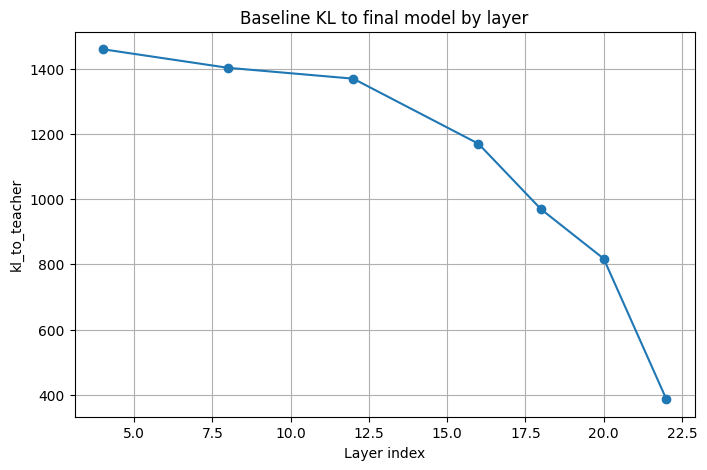

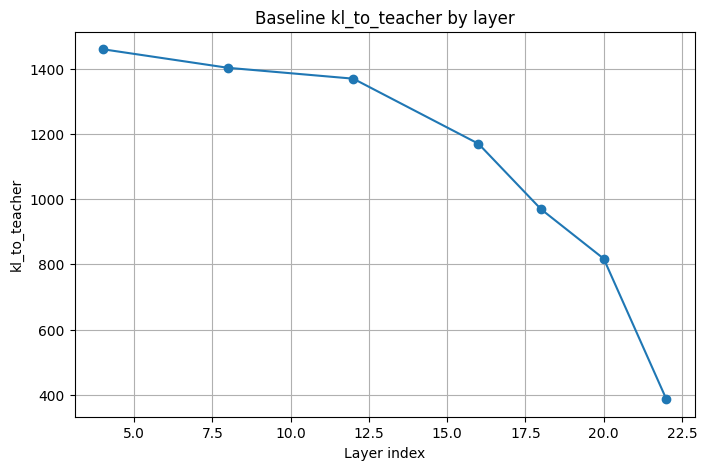

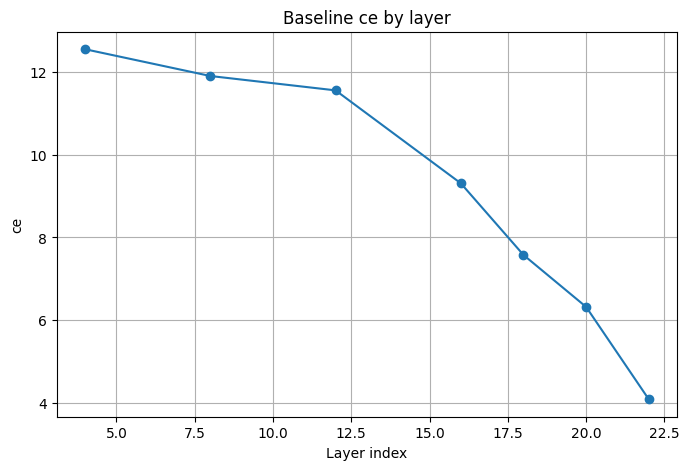

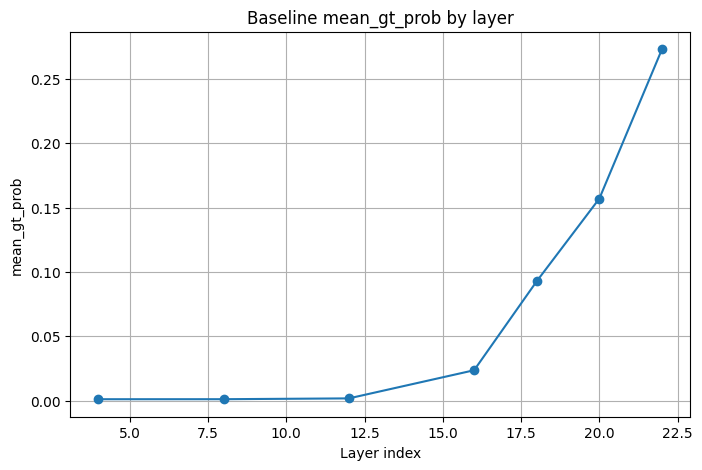

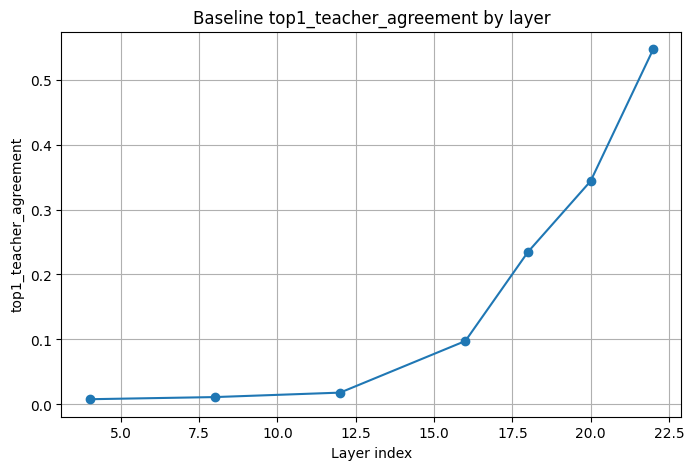

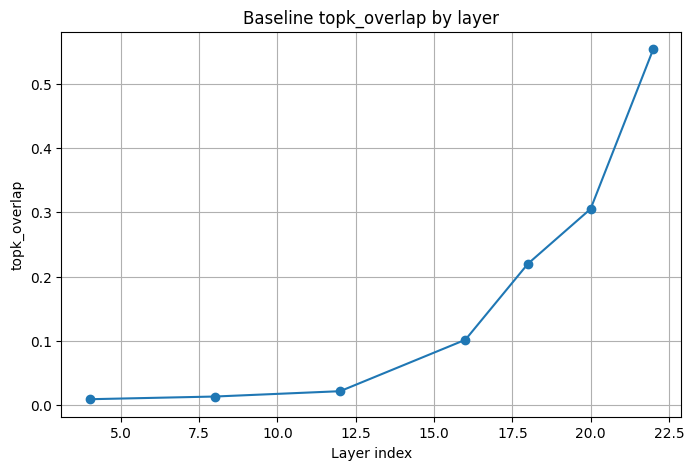

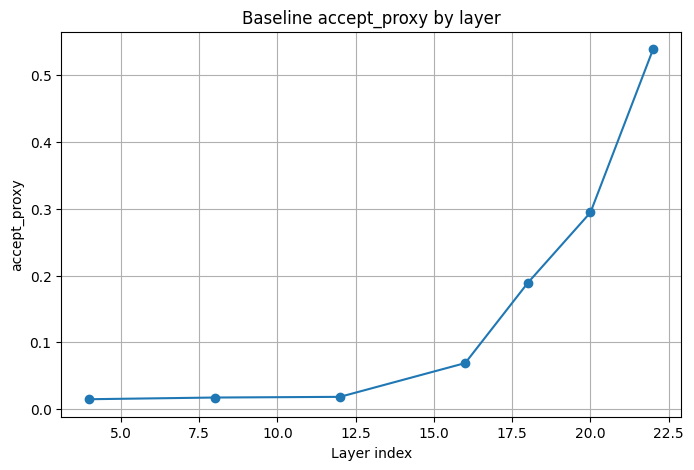

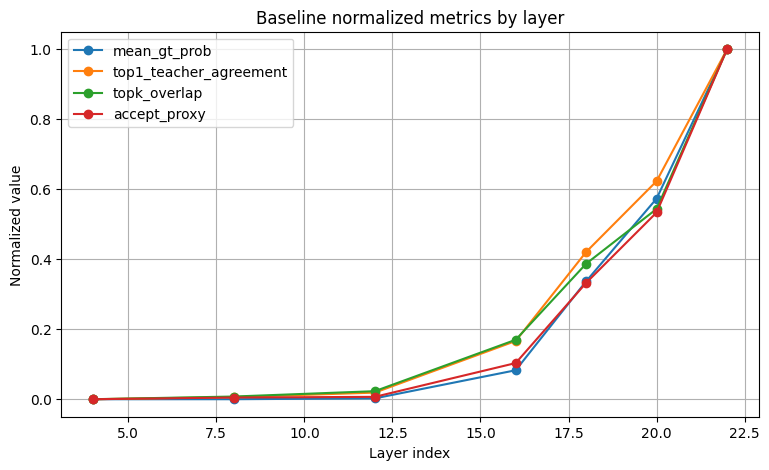

In [ ]:
plot_baseline_metric_by_layer(
    baseline_summary,
    metric="kl_to_teacher",
    title="Baseline KL to final model by layer",
)

plot_baseline_all_metrics(baseline_summary)
plot_baseline_normalized_metrics(baseline_summary)

In [ ]:
adapted_dataset = load_fineweb_stream(
    dataset_name="HuggingFaceFW/fineweb-edu",
    split="train",
    seed=999,
    buffer_size=10_000,
)

adapted_records_df, adapted_summary = layers_kl_over_data_rows(
    model=model,
    tokenizer=tokenizer,
    dataset=adapted_dataset,
    candidate_layers=[4, 8, 12, 16, 18, 20],
    adapters=adapters,
    run_name="adapted",
    seq_len=128,
    num_eval_rows=100,
    temperature=2.0,
    top_k=5,
    out_dir="data/layer_kl_compare",
)

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

adapted KL eval
num_layers: 24
candidate_layers: [4, 8, 12, 16, 18, 20]


adapted layer KL:   0%|          | 0/100 [00:00<?, ?it/s]

saved records: data/layer_kl_compare/adapted_layer_kl.jsonl
saved summary: data/layer_kl_compare/adapted_layer_kl_summary.json


In [ ]:
compare_summary = pd.concat(
    [baseline_summary, adapted_summary],
    ignore_index=True,
)

compare_summary

,run_name,layer_index,rows,n_tokens,kl_to_teacher,ce,perplexity,mean_gt_prob,top1_teacher_agreement,topk_overlap,accept_proxy
0,baseline,4,100,12700,1459.343469,12.552566,308052.510857,0.001019,0.008031,0.009339,0.014582
1,baseline,8,100,12700,1402.359823,11.904647,162899.948769,0.001034,0.011339,0.013528,0.017119
2,baseline,12,100,12700,1369.068558,11.557013,116010.002247,0.001667,0.018189,0.021827,0.018133
3,baseline,16,100,12700,1169.477443,9.308260,14202.892387,0.023548,0.097638,0.101795,0.068775
4,baseline,18,100,12700,968.601208,7.575194,2621.849609,0.092748,0.234724,0.220094,0.189015
5,baseline,20,100,12700,817.030527,6.318856,717.156337,0.157037,0.343701,0.305339,0.294519
6,baseline,22,100,12700,386.268348,4.084561,69.938498,0.273142,0.546693,0.553669,0.539170
7,adapted,4,100,12700,461.230521,6.154300,697.684332,0.122219,0.302205,0.342457,0.336494
8,adapted,8,100,12700,460.809866,6.115156,642.287002,0.125029,0.309213,0.346457,0.347772
9,adapted,12,100,12700,419.321906,5.780489,442.563332,0.134223,0.342126,0.369843,0.371215


In [ ]:
import matplotlib.pyplot as plt

def plot_baseline_vs_adapted(
    compare_summary,
    metric="kl_to_teacher",
):
    pivot = (
        compare_summary
        .pivot(
            index="layer_index",
            columns="run_name",
            values=metric,
        )
        .sort_index()
    )

    plt.figure(figsize=(8, 5))

    for col in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[col],
            marker="o",
            label=col,
        )

    plt.xlabel("Layer index")
    plt.ylabel(metric)
    plt.title(f"{metric}: baseline vs adapted")
    plt.grid(True)
    plt.legend()
    plt.show()

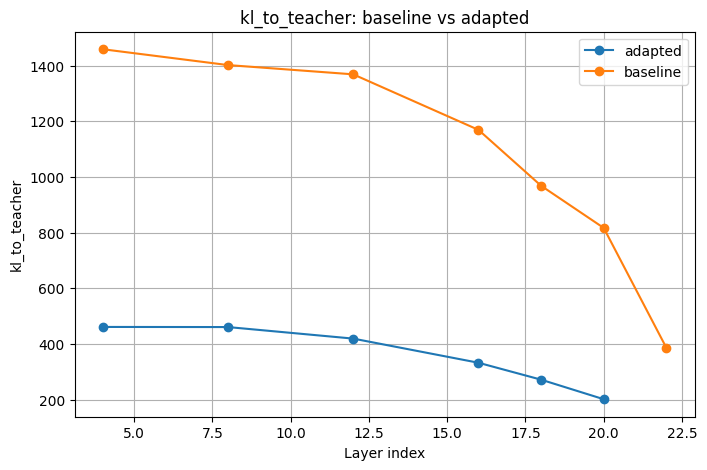

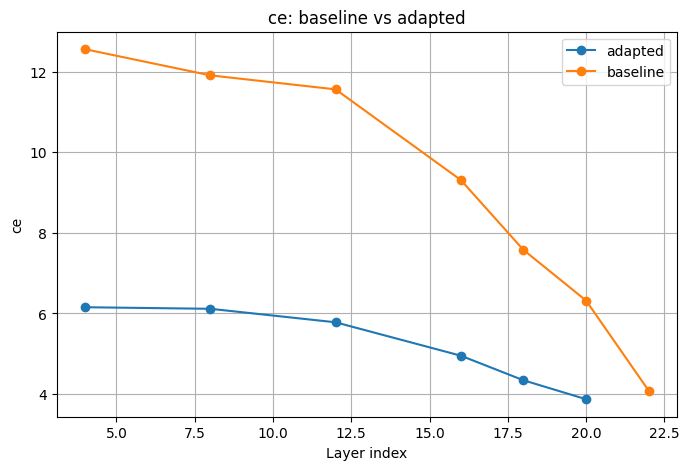

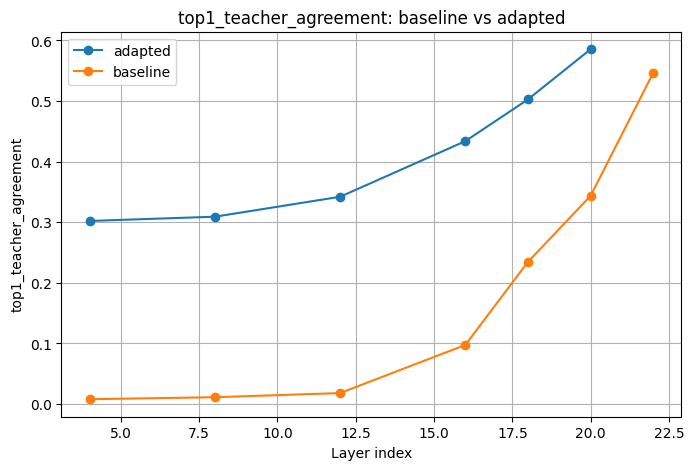

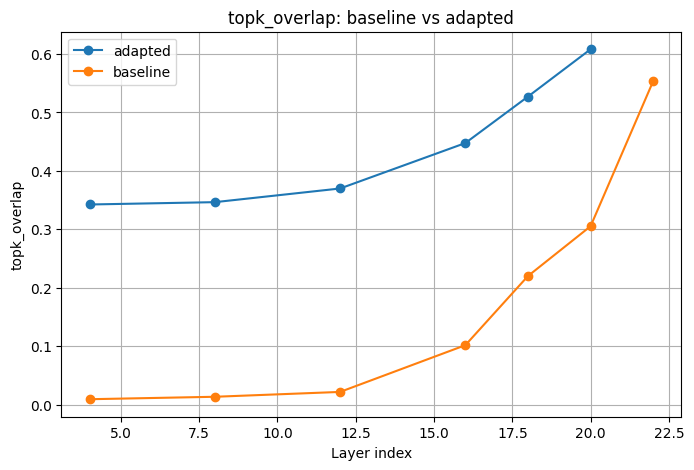

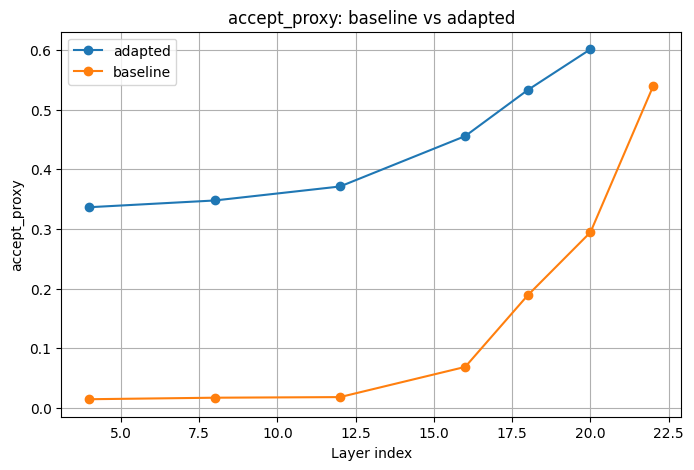

In [ ]:
plot_baseline_vs_adapted(compare_summary, metric="kl_to_teacher")
plot_baseline_vs_adapted(compare_summary, metric="ce")
plot_baseline_vs_adapted(compare_summary, metric="top1_teacher_agreement")
plot_baseline_vs_adapted(compare_summary, metric="topk_overlap")
plot_baseline_vs_adapted(compare_summary, metric="accept_proxy")

In [11]:
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


@torch.no_grad()
def hidden_distance_over_data_rows(
    model,
    tokenizer,
    dataset,
    candidate_layers,
    adapters=None,
    seq_len=128,
    num_eval_rows=100,
    out_dir="data/hidden_distance_eval",
):
    """
    Compare hidden-state distance to final layer.

    Baseline:
        early_h vs final_h

    Adapter:
        adapter(early_h) vs final_h

    Returns:
        records_df, summary
    """
    import os
    os.makedirs(out_dir, exist_ok=True)

    model.eval()
    device = next(model.parameters()).device
    model_dtype = next(model.parameters()).dtype

    if adapters is not None:
        adapters.eval()

    num_layers = len(model.model.layers)
    candidate_layers = [l for l in candidate_layers if l < num_layers]

    records = []
    valid_rows = 0
    seen_rows = 0

    pbar = tqdm(total=num_eval_rows, desc="Hidden distance eval")

    for example in dataset:
        if valid_rows >= num_eval_rows:
            break

        seen_rows += 1

        batch = tokenize_example(
            example=example,
            tokenizer=tokenizer,
            seq_len=seq_len,
            device=device,
        )

        if batch is None:
            continue

        input_ids, attention_mask = batch

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

        hidden_states = outputs.hidden_states

        # Final hidden before final norm / lm_head.
        final_h = hidden_states[-1][:, :-1, :].detach().float()

        for layer_index in candidate_layers:
            early_h = hidden_states[layer_index + 1][:, :-1, :].detach().float()

            # Baseline distance: early hidden to final hidden
            baseline_mse = F.mse_loss(early_h, final_h).item()
            baseline_cos_dist = (
                1.0 - F.cosine_similarity(
                    early_h.reshape(-1, early_h.shape[-1]),
                    final_h.reshape(-1, final_h.shape[-1]),
                    dim=-1,
                ).mean()
            ).item()

            record = {
                "valid_row_index": valid_rows,
                "seen_row_index": seen_rows,
                "layer_index": layer_index,
                "seq_len": seq_len,
                "baseline_mse": baseline_mse,
                "baseline_cos_dist": baseline_cos_dist,
            }

            # Adapter distance: adapter(early_h) to final hidden
            if adapters is not None and str(layer_index) in adapters:
                adapter = adapters[str(layer_index)]

                # Match adapter dtype
                adapter_dtype = next(adapter.parameters()).dtype
                adapted_h = adapter(early_h.to(device=device, dtype=adapter_dtype))
                adapted_h = adapted_h.float()

                adapter_mse = F.mse_loss(adapted_h, final_h).item()
                adapter_cos_dist = (
                    1.0 - F.cosine_similarity(
                        adapted_h.reshape(-1, adapted_h.shape[-1]),
                        final_h.reshape(-1, final_h.shape[-1]),
                        dim=-1,
                    ).mean()
                ).item()

                record["adapter_mse"] = adapter_mse
                record["adapter_cos_dist"] = adapter_cos_dist

            records.append(record)

        valid_rows += 1
        pbar.update(1)

    pbar.close()

    records_df = pd.DataFrame(records)

    summary = (
        records_df
        .groupby("layer_index")
        .mean(numeric_only=True)
        .reset_index()
    )

    records_path = f"{out_dir}/hidden_distance_records.jsonl"
    summary_path = f"{out_dir}/hidden_distance_summary.json"

    records_df.to_json(records_path, orient="records", lines=True)
    summary.to_json(summary_path, orient="records", indent=2)

    print("saved records:", records_path)
    print("saved summary:", summary_path)

    return records_df, summary

In [12]:
eval_dataset = load_fineweb_stream(
    dataset_name="HuggingFaceFW/fineweb-edu",
    split="train",
    seed=999,
    buffer_size=10_000,
)

hidden_records_df, hidden_summary = hidden_distance_over_data_rows(
    model=model,
    tokenizer=tokenizer,
    dataset=eval_dataset,
    candidate_layers=[4, 8, 12, 16, 18, 20],
    adapters=adapters,
    seq_len=128,
    num_eval_rows=100,
    out_dir="data/hidden_distance_eval",
)

hidden_summary

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Hidden distance eval:   0%|          | 0/100 [00:00<?, ?it/s]

saved records: data/hidden_distance_eval/hidden_distance_records.jsonl
saved summary: data/hidden_distance_eval/hidden_distance_summary.json


,layer_index,valid_row_index,seen_row_index,seq_len,baseline_mse,baseline_cos_dist,adapter_mse,adapter_cos_dist
0,4,49.5,50.5,128.0,11.986618,0.867216,11.036575,0.701047
1,8,49.5,50.5,128.0,11.948117,0.839076,11.032126,0.699403
2,12,49.5,50.5,128.0,11.887584,0.806883,10.798461,0.660075
3,16,49.5,50.5,128.0,11.427509,0.670046,NaN,NaN
4,18,49.5,50.5,128.0,11.060778,0.608839,NaN,NaN
5,20,49.5,50.5,128.0,10.497149,0.527512,NaN,NaN


In [ ]:
def plot_hidden_distance_comparison(
    hidden_summary,
    metric="mse",
):
    df = hidden_summary.sort_values("layer_index")

    if metric == "mse":
        baseline_col = "baseline_mse"
        adapter_col = "adapter_mse"
        ylabel = "MSE to final hidden state"
    elif metric == "cos":
        baseline_col = "baseline_cos_dist"
        adapter_col = "adapter_cos_dist"
        ylabel = "Cosine distance to final hidden state"
    else:
        raise ValueError("metric must be 'mse' or 'cos'")

    plt.figure(figsize=(8, 5))

    plt.plot(
        df["layer_index"],
        df[baseline_col],
        marker="o",
        label="No adapter",
    )

    if adapter_col in df.columns:
        plt.plot(
            df["layer_index"],
            df[adapter_col],
            marker="o",
            label="With adapter",
        )

    plt.xlabel("Layer index")
    plt.ylabel(ylabel)
    plt.title(f"Hidden-state distance to final layer ({metric})")
    plt.grid(True)
    plt.legend()
    plt.show()

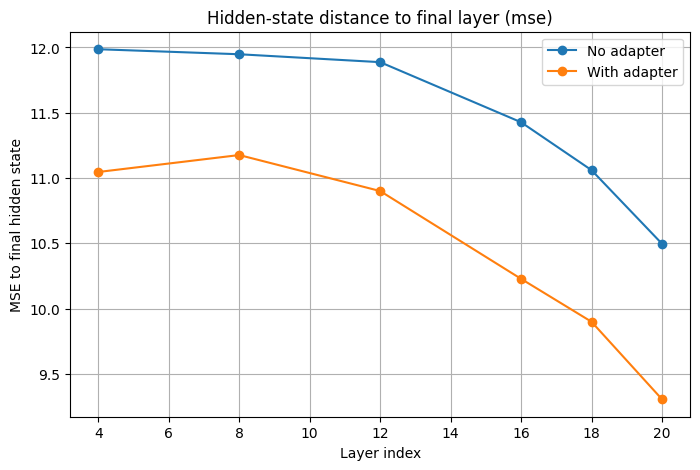

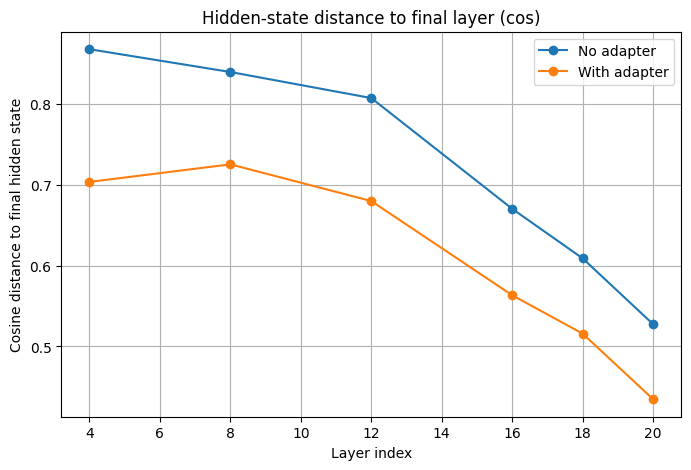

In [ ]:
plot_hidden_distance_comparison(hidden_summary, metric="mse")
plot_hidden_distance_comparison(hidden_summary, metric="cos")

***

### Logits Metrics between layers- Baseline

In [ ]:
# ============================================================
# 1. Imports
# ============================================================

import os
import math
import pandas as pd
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


# ============================================================
# 2. Functions
# ============================================================

def load_lm_model_and_tokenizer(model_name, device=None, dtype=None):
    hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if dtype is None:
        dtype = torch.bfloat16 if device == "cuda" else torch.float32

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        token=hf_token,
        trust_remote_code=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        token=hf_token,
        trust_remote_code=True,
    ).to(device)

    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model, tokenizer, device


def load_fineweb_stream(dataset_name, dataset_split, seed=42, buffer_size=10_000):
    dataset = load_dataset(
        dataset_name,
        split=dataset_split,
        streaming=True,
    )

    dataset = dataset.shuffle(
        seed=seed,
        buffer_size=buffer_size,
    )

    return dataset


def tokenize_row(example, tokenizer, seq_len, device):
    text = example.get("text", "")

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=seq_len,
    )

    input_ids = encoded["input_ids"]

    if input_ids.shape[1] < seq_len:
        return None

    input_ids = input_ids.to(device)
    attention_mask = torch.ones_like(input_ids, device=device)

    return {
        "text": text,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
    }


def hidden_to_logits(model, hidden_state, adapter=None):
    """
    Qwen/Llama-style:
        hidden -> final norm -> lm_head

    Later:
        hidden -> adapter -> final norm -> lm_head
    """
    if adapter is not None:
        hidden_state = adapter(hidden_state)

    hidden_state = model.model.norm(hidden_state)
    logits = model.lm_head(hidden_state)

    return logits


@torch.no_grad()
def compute_layer_metrics(
    student_logits,
    teacher_logits,
    input_ids,
    top_k=5,
    temperature=2.0,
):
    """
    Compare early-layer/student logits to final-layer/teacher logits.

    student_logits: [1, T, V]
    teacher_logits: [1, T, V]
    input_ids:      [1, T]

    We evaluate positions 0..T-2 because position t predicts token t+1.
    """
    student = student_logits[:, :-1, :].float()
    teacher = teacher_logits[:, :-1, :].float()
    labels = input_ids[:, 1:]

    B, Tm1, V = student.shape
    n_tokens = B * Tm1

    ce = F.cross_entropy(
        student.reshape(-1, V),
        labels.reshape(-1),
        reduction="mean",
    )

    student_probs = F.softmax(student, dim=-1)

    gt_probs = student_probs.gather(
        dim=-1,
        index=labels.unsqueeze(-1),
    ).squeeze(-1)

    mean_gt_prob = gt_probs.mean()

    Ttemp = temperature

    kl = F.kl_div(
        F.log_softmax(student / Ttemp, dim=-1),
        F.softmax(teacher / Ttemp, dim=-1),
        reduction="batchmean",
    ) * (Ttemp ** 2)

    teacher_top1 = teacher.argmax(dim=-1)
    student_top1 = student.argmax(dim=-1)

    top1_teacher_agreement = (
        teacher_top1 == student_top1
    ).float().mean()

    teacher_topk = teacher.topk(top_k, dim=-1).indices
    student_topk = student.topk(top_k, dim=-1).indices

    topk_overlap = (
        teacher_topk.unsqueeze(-1) == student_topk.unsqueeze(-2)
    ).any(dim=-1).float().mean()

    teacher_probs = F.softmax(teacher, dim=-1)
    q_probs = student_probs

    sampled = torch.multinomial(
        q_probs.reshape(-1, V),
        num_samples=1,
    ).reshape(B, Tm1)

    p_token = teacher_probs.gather(
        dim=-1,
        index=sampled.unsqueeze(-1),
    ).squeeze(-1)

    q_token = q_probs.gather(
        dim=-1,
        index=sampled.unsqueeze(-1),
    ).squeeze(-1)

    accept_proxy = torch.minimum(
        torch.ones_like(p_token),
        p_token / torch.clamp(q_token, min=1e-12),
    ).mean()

    return {
        "n_tokens": int(n_tokens),
        "ce": float(ce.item()),
        "perplexity": float(math.exp(min(ce.item(), 20))),
        "mean_gt_prob": float(mean_gt_prob.item()),
        "kl_to_teacher": float(kl.item()),
        "top1_teacher_agreement": float(top1_teacher_agreement.item()),
        f"top{top_k}_overlap": float(topk_overlap.item()),
        "accept_proxy": float(accept_proxy.item()),
    }


def save_jsonl(records, path):
    if len(records) == 0:
        return

    pd.DataFrame(records).to_json(
        path,
        orient="records",
        lines=True,
    )


def summarize_results(records, top_k=5):
    df = pd.DataFrame(records)

    summary = (
        df.groupby("layer_index")
        .agg(
            rows=("valid_row_index", "count"),
            n_tokens=("n_tokens", "sum"),
            ce=("ce", "mean"),
            perplexity=("perplexity", "mean"),
            mean_gt_prob=("mean_gt_prob", "mean"),
            kl_to_teacher=("kl_to_teacher", "mean"),
            top1_teacher_agreement=("top1_teacher_agreement", "mean"),
            topk_overlap=(f"top{top_k}_overlap", "mean"),
            accept_proxy=("accept_proxy", "mean"),
        )
        .reset_index()
    )

    return summary


@torch.no_grad()
def evaluate_early_layer_logits(
    model,
    tokenizer,
    dataset,
    candidate_layers,
    seq_len=128,
    num_eval_rows=100,
    top_k=5,
    out_dir="data/early_exit_eval",
    save_every=25,
    temperature=2.0,
):
    os.makedirs(out_dir, exist_ok=True)

    device = next(model.parameters()).device

    num_layers = len(model.model.layers)
    candidate_layers = [l for l in candidate_layers if l < num_layers]

    print("num layers:", num_layers)
    print("candidate layers:", candidate_layers)

    all_records = []
    buffer_records = []

    valid_rows = 0
    seen_rows = 0

    pbar = tqdm(total=num_eval_rows, desc="Evaluating rows")

    for example in dataset:
        if valid_rows >= num_eval_rows:
            break

        seen_rows += 1

        batch = tokenize_row(
            example=example,
            tokenizer=tokenizer,
            seq_len=seq_len,
            device=device,
        )

        if batch is None:
            continue

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

        teacher_logits = outputs.logits.detach()
        hidden_states = outputs.hidden_states

        text_preview = batch["text"][:300].replace("\n", " ")

        for layer_index in candidate_layers:
            early_hidden = hidden_states[layer_index + 1].detach()

            student_logits = hidden_to_logits(
                model=model,
                hidden_state=early_hidden,
                adapter=None,
            )

            metrics = compute_layer_metrics(
                student_logits=student_logits,
                teacher_logits=teacher_logits,
                input_ids=input_ids,
                top_k=top_k,
                temperature=temperature,
            )

            record = {
                "valid_row_index": valid_rows,
                "seen_row_index": seen_rows,
                "seq_len": seq_len,
                "layer_index": layer_index,
                "text_preview": text_preview,
                **metrics,
            }

            all_records.append(record)
            buffer_records.append(record)

        valid_rows += 1
        pbar.update(1)

        if valid_rows > 0 and valid_rows % save_every == 0:
            path = f"{out_dir}/eval_rows_{valid_rows}.jsonl"
            save_jsonl(buffer_records, path)
            print(f"saved {len(buffer_records)} records to {path}")
            buffer_records = []

    pbar.close()

    if len(buffer_records) > 0:
        path = f"{out_dir}/eval_rows_{valid_rows}_final.jsonl"
        save_jsonl(buffer_records, path)
        print(f"saved {len(buffer_records)} records to {path}")

    summary = summarize_results(
        records=all_records,
        top_k=top_k,
    )

    summary_path = f"{out_dir}/summary.json"
    summary.to_json(summary_path, orient="records", indent=2)

    print("saved summary to:", summary_path)

    return pd.DataFrame(all_records), summary

In [ ]:
import matplotlib.pyplot as plt


def plot_metric_by_layer(summary, metric, title=None):
    """
    Plot one metric across layers.
    """
    df = summary.sort_values("layer_index")

    plt.figure(figsize=(8, 5))
    plt.plot(df["layer_index"], df[metric], marker="o")
    plt.xlabel("Layer index")
    plt.ylabel(metric)

    if title is None:
        title = f"{metric} by layer"

    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_all_metrics_by_layer(summary, metrics=None):
    """
    Plot each metric separately across layers.
    """
    if metrics is None:
        metrics = [
            "ce",
            "perplexity",
            "mean_gt_prob",
            "kl_to_teacher",
            "top1_teacher_agreement",
            "topk_overlap",
            "accept_proxy",
        ]

    for metric in metrics:
        plot_metric_by_layer(
            summary=summary,
            metric=metric,
            title=f"{metric} by layer",
        )

In [ ]:
# ============================================================
# 3. Config
# ============================================================

model_name = "Qwen/Qwen3-1.7B-Base"  # replace with your Qwen3.5 checkpoint

dataset_name = "HuggingFaceFW/fineweb-edu"
dataset_split = "train"

seq_len = 128
num_eval_rows = 100

candidate_layers = [4, 8, 12, 16, 18, 20, 22, 24]
top_k = 5

out_dir = "data/early_exit_eval"


# ============================================================
# 4. Run pipeline
# ============================================================

model, tokenizer, device = load_lm_model_and_tokenizer(
    model_name=model_name,
)

dataset = load_fineweb_stream(
    dataset_name=dataset_name,
    dataset_split=dataset_split,
    seed=42,
    buffer_size=10_000,
)

records_df, summary = evaluate_early_layer_logits(
    model=model,
    tokenizer=tokenizer,
    dataset=dataset,
    candidate_layers=candidate_layers,
    seq_len=seq_len,
    num_eval_rows=num_eval_rows,
    top_k=top_k,
    out_dir=out_dir,
    save_every=25,
    temperature=2.0,
)

summary

In [ ]:
plot_all_metrics_by_layer(summary)

### Speculative Decoding

In [ ]:
import time
import numpy as np
import torch
import transformers
import torch.nn.functional as F
from tqdm.auto import tqdm


@torch.no_grad()
def draft_next_logits_from_layer(
    model,
    input_ids,
    layer_index,
    adapter=None,
):
    """
    Get next-token logits from an intermediate layer.

    If adapter is None:
        early_h -> norm -> lm_head

    If adapter is provided:
        early_h -> adapter -> norm -> lm_head
    """
    attention_mask = torch.ones_like(input_ids, device=input_ids.device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        return_dict=True,
    )

    early_h = outputs.hidden_states[layer_index + 1]  # [1, T, H]
    next_h = early_h[:, -1:, :]                       # [1, 1, H]

    if adapter is not None:
        adapter_dtype = next(adapter.parameters()).dtype
        next_h = next_h.to(dtype=adapter_dtype)
        next_h = adapter(next_h)

    model_dtype = next(model.parameters()).dtype
    next_h = next_h.to(dtype=model_dtype)

    next_h = model.model.norm(next_h)
    logits = model.lm_head(next_h)[:, -1, :]          # [1, vocab]

    return logits

In [ ]:
@torch.no_grad()
def generate_draft_tokens_from_layer(
    model,
    input_ids,
    layer_index,
    gamma=6,
    adapter=None,
    temperature=1.0,
):
    """
    Autoregressively generate gamma draft tokens using either:
      - baseline early layer
      - adapted early layer

    Returns:
        {
          "sequences": [1, T + gamma],
          "scores": list of gamma logits, each [1, vocab]
        }
    """
    generated = input_ids.clone()
    scores = []

    for _ in range(gamma):
        logits = draft_next_logits_from_layer(
            model=model,
            input_ids=generated,
            layer_index=layer_index,
            adapter=adapter,
        )

        probs = torch.softmax(logits.float() / temperature, dim=-1)
        next_token = torch.multinomial(probs[0], num_samples=1)  # [1]

        scores.append(logits)
        generated = torch.cat([generated, next_token.view(1, 1)], dim=-1)

    return {
        "sequences": generated,
        "scores": scores,
    }

In [ ]:
@torch.no_grad()
def run_speculative_eval(
    model,
    tokenizer,
    ds,
    layer_index,
    gamma=6,
    seqlen=10,
    num_prefix_tokens=10,
    num_of_examples=100,
    adapter=None,
    draft_temperature=1.0,
    device_type="cuda",
    print_every=1,
):
    """
    If adapter=None:
        baseline early-layer speculative decoding.

    If adapter is provided:
        adapted early-layer speculative decoding.

    Prints running metrics:
        idx, alpha, improvement, spec, vanilla, draft, verify, sample
    """

    def sync():
        if str(device_type).startswith("cuda") and torch.cuda.is_available():
            torch.cuda.synchronize()

    def now():
        sync()
        return time.time()

    n_accepted = 0
    n_generated = 0

    speculative_times = []
    vanilla_times = []

    draft_times = []
    verify_times = []
    sample_times = []

    example_count = 0

    transformers.set_seed(42)

    for idx, example in tqdm(enumerate(ds), total=num_of_examples):
        if example_count >= num_of_examples:
            break

        input_text = example["text"]

        input_ids = tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            max_length=max(num_prefix_tokens, 16),
        )["input_ids"].to(device_type)[0][:num_prefix_tokens]

        if input_ids.numel() < num_prefix_tokens:
            continue

        input_ids = input_ids[None]  # [1, T]
        all_ids = input_ids.clone()

        spec_start = now()

        while all_ids.shape[1] - input_ids.shape[1] < seqlen:
            # ----------------------------
            # 1. Draft gamma tokens
            # ----------------------------
            draft_start = now()

            draft_output = generate_draft_tokens_from_layer(
                model=model,
                input_ids=all_ids,
                layer_index=layer_index,
                gamma=gamma,
                adapter=adapter,
                temperature=draft_temperature,
            )

            draft_times.append(now() - draft_start)

            draft_sequences = draft_output["sequences"]  # [1, T + gamma]
            draft_tokens = draft_sequences[0, -gamma:]   # [gamma]

            q_logits = torch.stack(
                draft_output["scores"],
                dim=1,
            )[0]  # [gamma, vocab]

            q = torch.softmax(q_logits.float(), dim=-1)

            q_of_generated = q[
                torch.arange(gamma, device=device_type),
                draft_tokens,
            ]

            # ----------------------------
            # 2. Verify with full model
            # ----------------------------
            verify_start = now()

            attention_mask = torch.ones_like(
                draft_sequences,
                device=device_type,
            )

            p_logits = model(
                draft_sequences,
                attention_mask=attention_mask,
                return_dict=True,
            ).logits

            verify_times.append(now() - verify_start)

            # ----------------------------
            # 3. Acceptance + correction sample
            # ----------------------------
            sample_start = now()

            p = torch.softmax(
                p_logits[:, -gamma - 1:-1, :].float(),
                dim=-1,
            )[0]  # [gamma, vocab]

            p_of_generated = p[
                torch.arange(gamma, device=device_type),
                draft_tokens,
            ]

            ratio = p_of_generated / torch.clamp(
                q_of_generated,
                min=1e-12,
            )

            ratio = torch.clamp(ratio, max=1.0)

            is_accepted = (
                torch.rand(gamma, device=device_type) < ratio
            )

            index_to_reject = torch.argmin(
                torch.cat(
                    [
                        is_accepted,
                        torch.tensor([False], device=device_type),
                    ]
                ).int()
            ).item()

            accepted_tokens = draft_tokens[:index_to_reject]

            if index_to_reject == gamma:
                # all draft tokens accepted
                p_for_sample = p[-1]
            else:
                # first rejected token: sample from corrected distribution
                p_for_sample = p[index_to_reject] - q[index_to_reject]
                p_for_sample = torch.clamp(p_for_sample, min=0)
                p_for_sample = p_for_sample / torch.clamp(
                    p_for_sample.sum(),
                    min=1e-12,
                )

            n_accepted += index_to_reject
            n_generated += index_to_reject

            if index_to_reject < gamma:
                n_generated += 1

            big_token = torch.multinomial(
                p_for_sample,
                num_samples=1,
            )  # [1]

            new_tokens = torch.cat(
                [accepted_tokens, big_token],
                dim=0,
            ).view(1, -1)

            all_ids = torch.cat([all_ids, new_tokens], dim=-1)

            sample_times.append(now() - sample_start)

        speculative_times.append(now() - spec_start)

        # ----------------------------
        # 4. Vanilla generation timing
        # ----------------------------
        vanilla_start = now()

        attention_mask = torch.ones_like(input_ids, device=device_type)

        model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=all_ids.shape[1] - input_ids.shape[1],
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
        )

        vanilla_times.append(now() - vanilla_start)

        example_count += 1

        # ----------------------------
        # 5. Running print
        # ----------------------------
        alpha = n_accepted / max(n_generated, 1)

        mean_spec = np.mean(speculative_times)
        mean_vanilla = np.mean(vanilla_times)

        improvement = 1 - (mean_spec / mean_vanilla)

        if example_count % print_every == 0:
            print(
                f"idx={example_count - 1:03d} "
                f"alpha={alpha:.2%} "
                f"improvement={improvement:.4f} "
                f"spec={mean_spec:.4f}s "
                f"vanilla={mean_vanilla:.4f}s "
                f"draft={np.mean(draft_times):.4f}s "
                f"verify={np.mean(verify_times):.4f}s "
                f"sample={np.mean(sample_times):.4f}s"
            )

    alpha = n_accepted / max(n_generated, 1)
    speed_improvement = 1 - (
        np.mean(speculative_times) / np.mean(vanilla_times)
    )

    return {
        "layer_index": layer_index,
        "gamma": gamma,
        "seqlen": seqlen,
        "num_prefix_tokens": num_prefix_tokens,
        "num_examples": example_count,
        "alpha": float(alpha),
        "mean_speculative_time": float(np.mean(speculative_times)),
        "mean_vanilla_time": float(np.mean(vanilla_times)),
        "mean_draft_time": float(np.mean(draft_times)),
        "mean_verify_time": float(np.mean(verify_times)),
        "mean_sample_time": float(np.mean(sample_times)),
        "speed_improvement": float(speed_improvement),
        "n_accepted": int(n_accepted),
        "n_generated": int(n_generated),
    }

In [ ]:
dataset = load_fineweb_stream(
    dataset_name="HuggingFaceFW/fineweb-edu",
    split="train",
    seed=123,
    buffer_size=10_000,
)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

In [ ]:
model_name = "Qwen/Qwen3.5-2B"  # replace with your Qwen3.5 model if needed

model, tokenizer, device = load_lm_model_and_tokenizer(
    model_name=model_name,
)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
baseline_spec_result = run_speculative_eval(
    model=model,
    tokenizer=tokenizer,
    ds=dataset,
    layer_index=8,
    gamma=3,
    seqlen=10,
    num_prefix_tokens=10,
    num_of_examples=100,
    adapter=None,
    draft_temperature=0.8,
    device_type=device,
)

baseline_spec_result

  0%|          | 0/100 [00:00<?, ?it/s]

idx=000 alpha=0.00% improvement=-16.2605 spec=12.1845s vanilla=0.7059s draft=0.9155s verify=0.3011s sample=0.0013s
idx=001 alpha=0.00% improvement=-13.8076 spec=10.5192s vanilla=0.7104s draft=0.7895s verify=0.2607s sample=0.0012s
idx=002 alpha=0.00% improvement=-13.0730 spec=9.9550s vanilla=0.7074s draft=0.7475s verify=0.2464s sample=0.0012s
idx=003 alpha=0.00% improvement=-12.5942 spec=9.6897s vanilla=0.7128s draft=0.7271s verify=0.2403s sample=0.0012s
idx=004 alpha=0.00% improvement=-12.4126 spec=9.5231s vanilla=0.7100s draft=0.7149s verify=0.2358s sample=0.0011s
idx=005 alpha=0.00% improvement=-12.2757 spec=9.4095s vanilla=0.7088s draft=0.7066s verify=0.2327s sample=0.0011s
idx=006 alpha=1.43% improvement=-12.0146 spec=9.1842s vanilla=0.7057s draft=0.7000s verify=0.2302s sample=0.0011s
idx=007 alpha=1.25% improvement=-11.9712 spec=9.1235s vanilla=0.7034s draft=0.6941s verify=0.2283s sample=0.0011s
idx=008 alpha=1.11% improvement=-11.9108 spec=9.0635s vanilla=0.7020s draft=0.6882s ve

KeyboardInterrupt: 

In [ ]:
from huggingface_hub import hf_hub_download
import torch

repo_id = "Maorb23/qwen35-2b-early-exit-adapters"

ckpt_path = hf_hub_download(
    repo_id=repo_id,
    filename="adapters_final.pt",
    repo_type="model",
    token=os.environ.get("HF_TOKEN"),  # optional if public
)

ckpt = torch.load(
    ckpt_path,
    map_location=device,
)

In [ ]:
candidate_layers = ckpt["candidate_layers"]

adapters = build_adapters(
    model=model,
    candidate_layers=candidate_layers,
    device=device,
)

adapters.load_state_dict(ckpt["adapter_state_dict"])
adapters.eval()

ModuleDict(
  (4): ResidualLinearAdapter(
    (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (8): ResidualLinearAdapter(
    (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (12): ResidualLinearAdapter(
    (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (16): ResidualLinearAdapter(
    (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (18): ResidualLinearAdapter(
    (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (20): ResidualLinearAdapter(
    (ln): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (proj): Linear(in_features=2048, out_features=2048, bia

In [ ]:
adapted_spec_result = run_speculative_eval(
    model=model,
    tokenizer=tokenizer,
    ds=dataset,
    layer_index=12,
    gamma=4,
    seqlen=10,
    num_prefix_tokens=10,
    num_of_examples=100,
    adapter=adapters["8"],
    draft_temperature=0.8,
    device_type=device,
)

adapted_spec_result

  0%|          | 0/100 [00:00<?, ?it/s]

***

## Push To Huggingface

In [13]:
from huggingface_hub import login
import os

login()

In [ ]:
readme = """
# Qwen3.5-2B Early Exit Adapters

Adapters trained to map intermediate hidden states to final-model-like next-token distributions.

Base model: Qwen/Qwen3.5-2B
Layers: [4, 8, 12, 16, 18, 20]
Sequence length: 128
Training steps: 500
Loss: KL distillation to final logits
"""

with open("data/early_exit_adapters/README.md", "w") as f:
    f.write(readme)

In [14]:
from huggingface_hub import HfApi
from datetime import datetime
import os

api = HfApi()

repo_id = "Maorb23/qwen35-2b-early-exit-adapters"

api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True,
)

run_name = datetime.now().strftime("run_%Y%m%d_%H%M%S")

api.upload_folder(
    repo_id=repo_id,
    repo_type="model",
    folder_path="data/early_exit_adapters",
    path_in_repo=f"runs/{run_name}",
    commit_message=f"Upload adapters {run_name}",
)

CommitInfo(commit_url='https://huggingface.co/Maorb23/qwen35-2b-early-exit-adapters/commit/14fc31922064d2cf1d079aadc2b7e90106a56868', commit_message='Upload adapters run_20260628_125648', commit_description='', oid='14fc31922064d2cf1d079aadc2b7e90106a56868', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Maorb23/qwen35-2b-early-exit-adapters', endpoint='https://huggingface.co', repo_type='model', repo_id='Maorb23/qwen35-2b-early-exit-adapters'), pr_revision=None, pr_num=None)